In [1]:
import pandas as pd

# Load the cleaned dataset (adjust path if needed)
df = pd.read_csv(r"E:\BISI\Project\sentimentalanalysis\data\cleaned\Cleaned Subset 3.csv")

In [2]:
# Sentiment Bucketing Script
def classify_sentiment(score):
    if pd.isna(score):
        return "Unknown"
    elif score >= 80:
        return "Positive"
    elif score >= 60:
        return "Neutral"
    else:
        return "Negative"

df["sentiment_label"] = df["score100"].apply(classify_sentiment)


<Axes: xlabel='surveyr'>

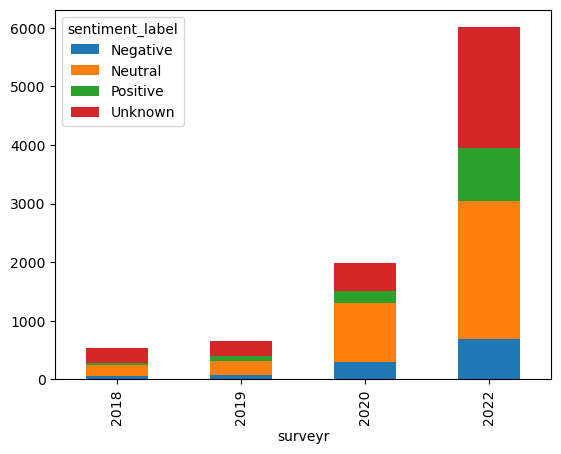

In [3]:
# Trend Analysis Script
df.groupby(["surveyr", "sentiment_label"]).size().unstack().plot(kind="bar", stacked=True)


In [4]:
# Top Questions Script
top_questions = df.sort_values(by="score100", ascending=False).head(3)
top_questions[["question", "title_e", "score100"]]

,question,title_e,score100
3388,Q31,Question 31. When I communicate with my immedi...,97.0
3409,Q31,Question 31. When I communicate with my immedi...,97.0
3391,Q31,Question 31. When I communicate with my immedi...,97.0


In [5]:
# Bottom Questions Script
bottom_questions = df.sort_values(by="score100", ascending=True).head(3)
bottom_questions[["question", "title_e", "score100"]]

,question,title_e,score100
2132,Q18f,Question 18f. I feel that the quality of my wo...,32.0
2128,Q18f,Question 18f. I feel that the quality of my wo...,34.0
1737,Q18b,Question 18b. I feel that the quality of my wo...,34.0


In [6]:

# Define the five gender identities
target_genders = [
    "Man",
    "Woman",
    "2SLGBTQIA+: Gay",
    "2SLGBTQIA+: Lesbian",
    "2SLGBTQIA+: Transgender"
]

# Filter to just those rows
filtered_df = df[df["descrip_e"].isin(target_genders)].copy()

In [7]:
%matplotlib inline

In [8]:

# Remove Unknown sentiment rows
filtered_df = filtered_df[filtered_df["sentiment_label"] != "Unknown"]

# Count responses
sentiment_counts = (
    filtered_df
    .groupby(["descrip_e", "sentiment_label"])
    .size()
    .reset_index(name="count")
)

# Compute percentages per gender group
total_per_gender = sentiment_counts.groupby("descrip_e")["count"].transform("sum")
sentiment_counts["percentage"] = (sentiment_counts["count"] / total_per_gender) * 100

# Pivot into table format (genders as rows, sentiments as columns
pivot_table = (
    sentiment_counts
    .pivot(index="descrip_e", columns="sentiment_label", values="percentage")
    .fillna(0)
    .round(2)
)

# Display the result
pivot_table


sentiment_label,Negative,Neutral,Positive
descrip_e,,,
2SLGBTQIA+: Gay,19.70,57.58,22.73
2SLGBTQIA+: Lesbian,12.12,62.12,25.76
Man,15.42,59.03,25.55
Woman,15.86,61.23,22.91
